In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


### Practising Structed dataprocessing with Sklearn

In [ ]:
train = pd.read_csv("comment-category-prediction-challenge/train.csv") 
test = pd.read_csv("comment-category-prediction-challenge/test.csv") 

test["is_train"] = 0
train["is_train"] = 1
sample = pd.read_csv("comment-category-prediction-challenge/Sample.csv") 

In [ ]:
df = pd.concat([train, test], ignore_index=True)

In [ ]:
df.info()

In [ ]:
df["created_date"].head()

In [ ]:
df["created_date"] = pd.to_datetime(df["created_date"], yearfirst=True)


In [ ]:
df['Day'] = df["created_date"].dt.day.astype(int)
df['Month'] = df["created_date"].dt.month.astype(int)
df['Year'] = df["created_date"].dt.year.astype(int)
df['weekday'] = df["created_date"].dt.weekday.astype(int) #to fetch the weekends
df['created_hour'] = df["created_date"].dt.hour

In [ ]:
num_cols = [i for i in df.select_dtypes(["int64", "float64"])]
cat_cols = [i for i in df.columns if i not in num_cols]

In [ ]:
num_cols, cat_cols

In [ ]:
df.nunique()

In [ ]:
df["disability"] = df["disability"].astype("int64")

### Handling comments

In [ ]:
df["comment"] = df["comment"].str.strip()

In [ ]:
df["comment"] = df["comment"].apply(lambda x: x if isinstance(x, str) and len(x) > 0 else np.nan)
df = df.dropna(subset="comment")

# df["comment"].apply(lambda x: np.nan if len(x)<=0 else x)
# for i,x in enumerate(df["comment"]):
#     x = np.nan if len(x)<=0 else x
#     print(i)

In [ ]:
df["comment"] = df["comment"].str.replace('\n', ' ')
df['comment'] = df['comment'].str.replace(r'http\S+', '', regex=True)
df['comment'] = df['comment'].str.replace(r'\s+', ' ', regex=True)
df['comment'] = df['comment'].str.replace(r'-{2,}', ' ', regex=True)

In [ ]:
df["word_len"] = df["comment"].str.split().str.len()
df["comment_len"] = df["comment"].str.strip().str.len()
df["avg_words"] = df["comment_len"]/df['word_len']+1
df["word_len"] = df["word_len"].replace(0, 1)

In [ ]:
df["num_!"] = df["comment"].str.count("!")
df['num_ques'] = df['comment'].str.count(r'\?')

In [ ]:
df["emojis_net"] = df["emoticon_1"] + df["emoticon_2"]+ df["emoticon_3"]

Handling Missing values

In [ ]:
df[df["avg_words"].isna()]["comment"]
df =df.dropna(subset= "avg_words")

In [ ]:
df.isna().sum()

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

from tqdm.auto import tqdm

sia = SentimentIntensityAnalyzer()


In [268]:
# sia.polarity_scores(df["comment"])
sentiment_scores = [sia.polarity_scores(i)["compound"] for i in tqdm(df["comment"])]

In [269]:
df["sentiment_scores"] = sentiment_scores

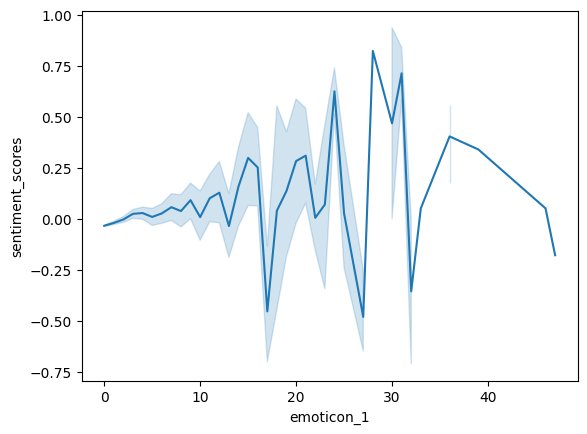

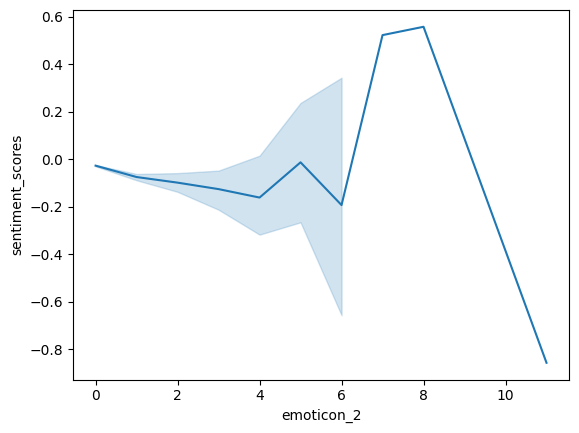

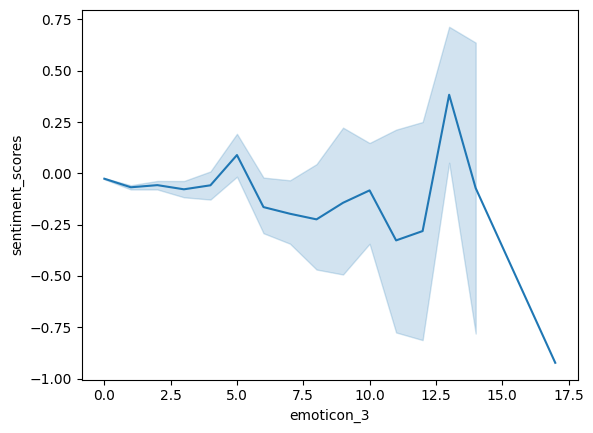

<Axes: xlabel='emojis_net', ylabel='sentiment_scores'>

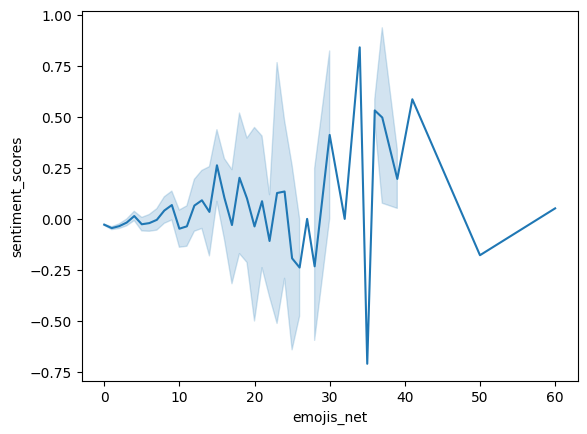

In [270]:
# sns.histplot(data = df[:1000], x = "sentiment_scores", y = "emojis_net", bins = 10)

for i in ["emoticon_1","emoticon_2","emoticon_3"]:
    sns.lineplot(data = df[df["is_train"] == 1], y = "sentiment_scores", x = i)
    plt.show()

sns.lineplot(data = df[df["is_train"] == 1], y = "sentiment_scores", x = "emojis_net")

In [271]:
df['votes_ratio'] = df['upvote']/(df['upvote']+df['downvote']+ 1e-9)

# i'd somehow ignored the if_1 and 2 so let's resolve it - it'll give some boost to f1_score

df["if_1_log"] = np.log1p(df["if_1"]) #there are outliers
df["if_2_log"] = np.log1p(df["if_2"])

df["if_interaction_log"] = df["if_1_log"] * df["if_2_log"]

In [272]:
df['upvote_log1'] = np.log1p(df['upvote'])
df['downvote_log1'] = np.log1p(df['downvote'])

#engagement scorea nd intensiryt
df['engagement_score'] = df['upvote'] - df['downvote']
df['emoticon_density'] = df['emojis_net'] / (df['word_len'] + 1)

# Handling the missing values in the dataset

In [273]:
df[["race","religion","gender"]] = df[["race","religion","gender"]].fillna("Missing")

In [310]:
df["is_trans"] = (df["gender"]== "transgender").astype(int)

In [313]:
df[["race","religion","gender"]] = df[["race","religion","gender"]].replace(["none", "Missing"], "Unknow")

### Splitting dataset into train and test set

In [315]:
train_df = df[df["is_train"]==1].drop(["is_train", "created_date", "post_id"], axis = 1)
test_df = df[df["is_train"]==0].drop(["is_train", "created_date", "post_id"], axis = 1)

In [316]:
train_df.columns, test_df.columns

(Index(['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1',
        'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'label',
        'Day', 'Month', 'Year', 'weekday', 'created_hour', 'word_len',
        'comment_len', 'avg_words', 'num_!', 'num_ques', 'emojis_net',
        'sentiment_scores', 'votes_ratio', 'if_1_log', 'if_2_log',
        'if_interaction_log', 'upvote_log1', 'downvote_log1',
        'engagement_score', 'emoticon_density', 'is_trans'],
       dtype='str'),
 Index(['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1',
        'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'label',
        'Day', 'Month', 'Year', 'weekday', 'created_hour', 'word_len',
        'comment_len', 'avg_words', 'num_!', 'num_ques', 'emojis_net',
        'sentiment_scores', 'votes_ratio', 'if_1_log', 'if_2_log',
        'if_interaction_log', 'upvote_log1', 'downvote_log1',
        'engagement_score', 'emoticon_density', 'is_tran

In [317]:
from sklearn.model_selection import train_test_split
X = train_df.drop(["label"], axis = 1)
y = train_df["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    random_state= 42,
    test_size=0.3
)

In [318]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((138529, 33), (59370, 33), (138529,), (59370,))

In [319]:
num_cols = [i for i in train_df.select_dtypes(["int64", "float64"]) if i != "label"]
cat_cols = [i for i in train_df.columns if i not in num_cols]
num_cols, cat_cols

(['emoticon_1',
  'emoticon_2',
  'emoticon_3',
  'upvote',
  'downvote',
  'if_1',
  'if_2',
  'disability',
  'Day',
  'Month',
  'Year',
  'weekday',
  'word_len',
  'comment_len',
  'avg_words',
  'num_!',
  'num_ques',
  'emojis_net',
  'sentiment_scores',
  'votes_ratio',
  'if_1_log',
  'if_2_log',
  'if_interaction_log',
  'upvote_log1',
  'downvote_log1',
  'engagement_score',
  'emoticon_density',
  'is_trans'],
 ['race', 'religion', 'gender', 'comment', 'label', 'created_hour'])

## Feature selection

A dataset with 200k rows and 30 columns is often easier than 15k rows that explode into 5,000 one-hot columns.

https://scikit-learn.org/stable/modules/feature_selection.html

### Numerical features:
1. VarianceThreshold: Remove features with low variance. 
    - selector.fit_transform(X_train)
    - selector.get_support() to get the boolean mask of selected features
2. SelectKBest: Select the top k features based on a scoring function.(very common)
    - selector.fit_transform(X_train, y_train)
    - selector.get_support() to get the boolean mask of selected features
    - selector.scores_ to get the scores of each feature
3. 
### Categorical features:
1. 

```python
# to view the featuers 
selected_features = df[num_cols].columns[selector.get_support()]
removed_features = df[num_cols].columns[~selector.get_support()]

print("Selected:", list(selected_features))
print("Removed:", list(removed_features))

## to view the scores of each feature
feature_scores = pd.DataFrame({
    "Features": df[num_cols].columns,
    'Score': selector.scores_
}).sort_values(by = "Score", ascending=False)
print(feature_scores)
```

In [320]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif, chi2
selector = SelectKBest(score_func= mutual_info_classif, k = 15)
X_reduced = selector.fit_transform(X_train[['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2','disability','Day','Month','Year','weekday','word_len','comment_len','avg_words','num_!','num_ques','emojis_net','sentiment_scores','votes_ratio','if_1_log','if_2_log','if_interaction_log','upvote_log1','downvote_log1','engagement_score','emoticon_density']], y_train)

In [321]:
X_train["gender"].unique()

<StringArray>
['Unknow', 'male', 'female', 'transgender', 'other']
Length: 5, dtype: str

In [291]:
from sklearn.feature_selection import chi2
selector_cat = SelectKBest(score_func= chi2)
X_reduced = selector.fit_transform(X_train[['race', 'religion', 'gender']], y_train)


/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=15 is greater than n_features=3. All the features will be returned.
  warnings.warn(


ValueError: could not convert string to float: 'none'

In [287]:
X_reduced.shape, df[num_cols].shape

((138529, 15), (299861, 27))

In [288]:
# to view the featuers 
selected_features = df[num_cols].columns[selector.get_support()]
removed_features = df[num_cols].columns[~selector.get_support()]

print("Selected:", list(selected_features))
print("Removed:", list(removed_features))

Selected: ['if_1', 'if_2', 'Day', 'Year', 'word_len', 'comment_len', 'avg_words', 'sentiment_scores', 'votes_ratio', 'if_1_log', 'if_2_log', 'if_interaction_log', 'upvote_log1', 'downvote_log1', 'emoticon_density']
Removed: ['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'disability', 'Month', 'weekday', 'num_!', 'num_ques', 'emojis_net', 'engagement_score']


In [289]:
feature_scores = pd.DataFrame({
    "Features": df[num_cols].columns,
    'Score': selector.scores_
}).sort_values(by = "Score", ascending=False)
print(feature_scores)

              Features     Score
21            if_2_log  0.500484
6                 if_2  0.495763
22  if_interaction_log  0.154208
5                 if_1  0.065678
20            if_1_log  0.065577
18    sentiment_scores  0.039080
14           avg_words  0.011935
13         comment_len  0.011088
12            word_len  0.006635
19         votes_ratio  0.005981
24       downvote_log1  0.004169
10                Year  0.003869
26    emoticon_density  0.003332
23         upvote_log1  0.002943
8                  Day  0.002667
25    engagement_score  0.002667
9                Month  0.002517
16            num_ques  0.002322
3               upvote  0.001992
4             downvote  0.001936
0           emoticon_1  0.001633
15               num_!  0.001165
2           emoticon_3  0.001091
7           disability  0.000566
11             weekday  0.000564
1           emoticon_2  0.000435
17          emojis_net  0.000000


In [335]:
num_cols = ['if_1', 'if_2', 'Day', 'Year', 'word_len', 'comment_len', 'avg_words', 'sentiment_scores', 'votes_ratio', 'if_1_log', 'if_2_log', 'if_interaction_log', 'upvote_log1', 'downvote_log1', 'emoticon_density']
cat_cols = ["race", "gender", "religion"]


In [354]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
# basically while making pipeline remember : Pipeline([("name", "to_apply_function(dum= ""...)")])


cat_transformer = Pipeline([
    ("ohe", OneHotEncoder(handle_unknown="ignore")) #we just want to encode the cats
])
num_transformer = Pipeline([
    ("scaler", RobustScaler()) #jsut for num_cols
])

# and for as column transformer souds it's simple: ColumnTranformer(tranformer= [("name_", what_to apply, where_to_apply)])
preprocessor = ColumnTransformer(
    transformers=[
        ("nums", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)

pipleline_ = Pipeline([
    ("prep", preprocessor),
    ('select', SelectKBest(score_func=mutual_info_classif, k = 15)),
    ('model', LogisticRegression(class_weight= 'balanced',max_iter=500))
])

In [355]:
whole_pipe = pipleline_.fit(X_train, y_train)

In [376]:
whole_pipe["model"].coef_

array([[ 2.55034362e-03,  1.44802861e+00, -4.69724211e-02,
         3.83626491e-01,  1.04658567e-01,  5.01281279e-01,
        -3.79193234e-01, -6.72925619e+00,  1.30467358e-01,
        -2.72194940e-02, -3.82048073e-01, -2.80773681e-01,
         1.45561267e-01, -5.41165222e-02, -5.55228888e-01],
       [-2.76103616e-03, -7.85167956e-01, -1.61462044e+00,
         1.47198570e+00,  9.89016253e-02,  6.05184370e-02,
         4.67084248e-01,  3.30831386e+00,  1.08751233e-01,
        -6.07448696e-01,  1.84927399e+00,  1.36295681e+00,
        -2.75813513e-01, -1.25455180e+00,  7.66055400e-01],
       [ 1.43013501e-03, -1.80952692e-01, -1.99325625e-01,
         4.97209116e-01,  7.20163953e-02, -2.92514936e-02,
        -1.26894513e-01,  1.13406365e+00, -2.80979922e-02,
         4.16783017e-01, -5.59619918e-01, -3.02119259e-01,
         1.46363107e-01,  7.56813309e-01, -3.74221251e-01],
       [-1.21944247e-03, -4.81907957e-01,  1.86091848e+00,
        -2.35282131e+00, -2.75576587e-01, -5.32548222

In [357]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_val, whole_pipe.predict(X_val)))

              precision    recall  f1-score   support

         0.0       0.96      0.94      0.95     34337
         1.0       0.62      0.73      0.67      4772
         2.0       0.82      0.47      0.60     18570
         3.0       0.12      0.68      0.20      1691

    accuracy                           0.77     59370
   macro avg       0.63      0.70      0.60     59370
weighted avg       0.87      0.77      0.80     59370



In [380]:
whole_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('select', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nums', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

## Interpreting Pipelines:
##### Remember: 
```Pipeline  ->  ColumnTransformer  ->  Individual Transformers / Models```

Rules: 
- "named_steps -> Pipeline"
- "named_transformers_ -> ColumnTransformer"
- "attributes -> individual models"  

that's it, don't overcomplicate shitt.\ (use dir(...) if stuck)


### Pipeline Access:
1. Access by name: 
```python
whole_pipe["prep"]
whole_pipe["select"]
whole_pipe["model"]
```
2. Access by named_step:
```python
whole_pipe.named_steps["prep"]
whole_pipe.named_steps["select"]
whole_pipe.named_steps["model"]
```
both work the same way.. but prefer the named_steps one its more explicit and cleaner.. 

#### Accessing the individual transformers/models:
eg:
```python
prep = whole_pipe.named_steps["prep"]
prep.transformers_
prep.get_params()
prep.get_params().keys()
prep.named_transformers_["num"]
prep.named_transformers_["num"].get_params().keys()
```
#### Back tracing the pipeline:
```python
select = whole_pipe["select"] #imagine like pointer on __ pipe
all_features = prep.get_feature_names_out() #going in the pipe and fetching the feature names out
mask = select.get_support() #getting the bool mask of selected features
selected_features = all_features[mask] #simply apply the bool to get the featuer name out
selected_features 
```


#####\
```markdown
Pipeline (main)
  ├── prep (sub)
  │     ├── nums (file)
  │     └── cat (file)
  ├── select (file)
  └── model (file)```

In [372]:
prep = whole_pipe.named_steps["prep"]

prep.named_transformers_["nums"].get_params()

{'memory': None,
 'steps': [('scaler', RobustScaler())],
 'transform_input': None,
 'verbose': False,
 'scaler': RobustScaler(),
 'scaler__copy': True,
 'scaler__quantile_range': (25.0, 75.0),
 'scaler__unit_variance': False,
 'scaler__with_centering': True,
 'scaler__with_scaling': True}

array(['nums__if_1', 'nums__if_2', 'nums__word_len', 'nums__comment_len',
       'nums__avg_words', 'nums__sentiment_scores', 'nums__if_1_log',
       'nums__if_2_log', 'nums__if_interaction_log', 'cat__race_Unknow',
       'cat__race_black', 'cat__race_white', 'cat__gender_Unknow',
       'cat__religion_Unknow', 'cat__religion_muslim'], dtype=object)

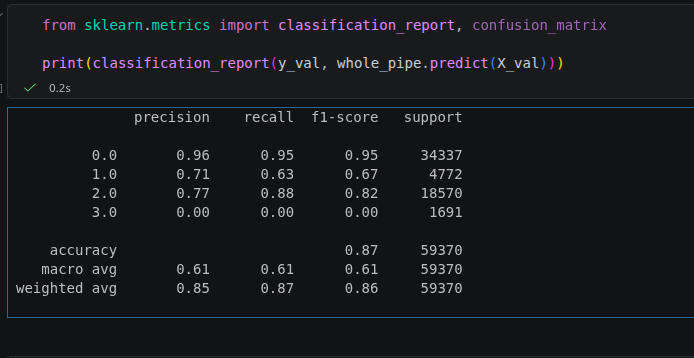

In [342]:
feature_scores = pd.DataFrame({
    "Features": df[num_cols].columns,
    'Score': whole_pipe.scores_
}).sort_values(by = "Score", ascending=False)
print(feature_scores)

AttributeError: 'Pipeline' object has no attribute 'scores_'

In [337]:
# performing ohe on cat cols
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(test_df)


ValueError: A given column is not a column of the dataframe